<a href="https://colab.research.google.com/github/shifa441/Neural_Network_assignment/blob/main/problem_set_01/problem_set_01_id-223017812(cnn_xray).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
train_dir = "/content/drive/MyDrive/Archive/train"
val_dir = "/content/drive/MyDrive/Archive/val"
test_dir = "/content/drive/MyDrive/Archive/test"

print("Train path exists:", os.path.exists(train_dir))
print("Validation path exists:", os.path.exists(val_dir))
print("Test path exists:", os.path.exists(test_dir))

Train path exists: True
Validation path exists: True
Test path exists: True


In [10]:
print("Train folders:", os.listdir(train_dir))
print("Validation folders:", os.listdir(val_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['PNEUMONIA', 'NORMAL']
Validation folders: ['PNEUMONIA', 'NORMAL']
Test folders: ['PNEUMONIA', 'NORMAL']


In [36]:
image_h = 128
imag2_w = 128
batch_size = 32

In [37]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [41]:
print("Class label:", train_generator.class_indices)

Class label: {'NORMAL': 0, 'PNEUMONIA': 1}


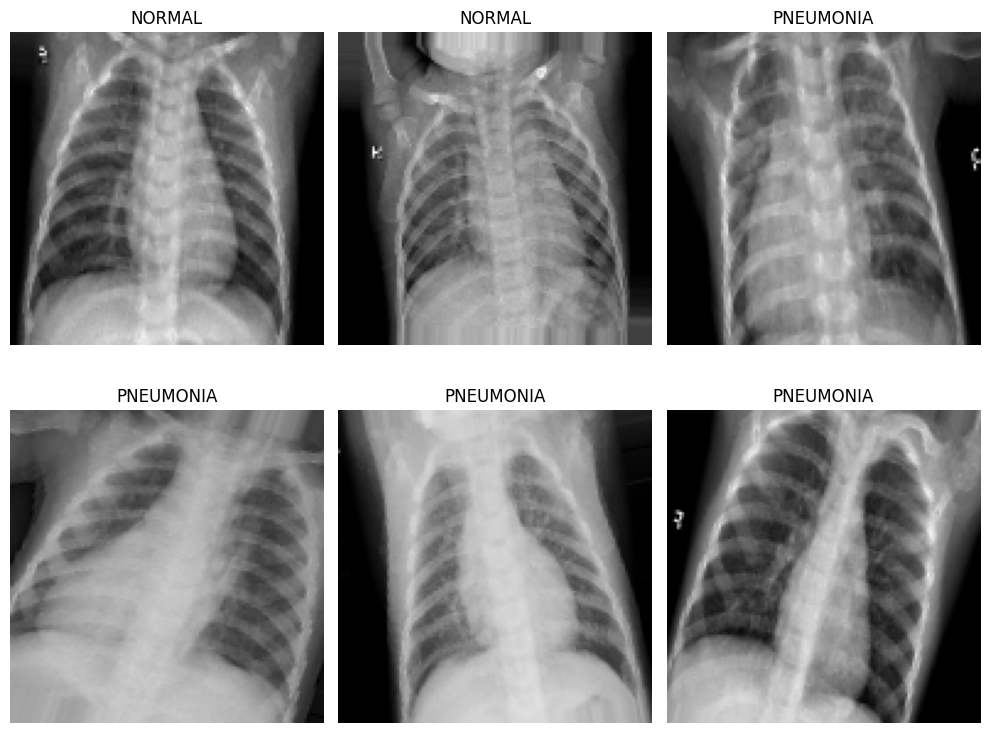

In [42]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i] == 1 else "NORMAL")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [45]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(img_height, img_width, 3)),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.6),
    Dense(1, activation='sigmoid')
])

In [46]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,529 (3.15 MB)

 Trainable params: 826,529 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [48]:
class_weight = {0: 2.0, 1: 1.0}

In [49]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop],
    class_weight=class_weight
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.7419 - loss: 0.7423 - val_accuracy: 0.8125 - val_loss: 0.4422
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.8420 - loss: 0.4806 - val_accuracy: 0.9375 - val_loss: 0.3262
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.8604 - loss: 0.4484 - val_accuracy: 0.9375 - val_loss: 0.4529
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.8708 - loss: 0.4062 - val_accuracy: 0.6875 - val_loss: 0.6937


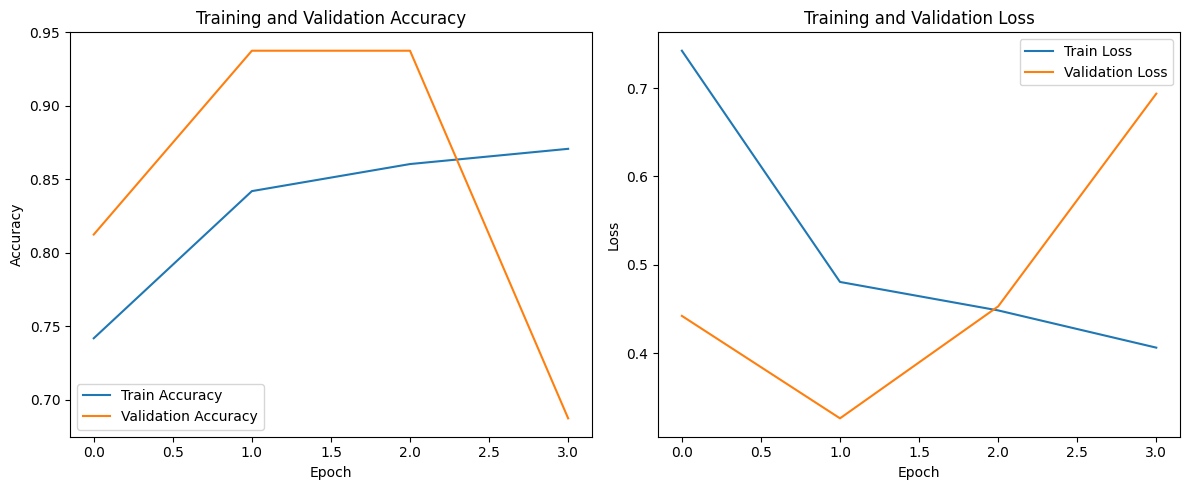

In [50]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [51]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 516ms/step - accuracy: 0.8654 - loss: 0.3155
Test Loss: 0.3155
Test Accuracy: 0.8654


In [52]:
pred_probs = model.predict(test_generator)
y_pred = (pred_probs > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 442ms/step
Confusion Matrix:
[[179  55]
 [ 29 361]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.86      0.76      0.81       234
   PNEUMONIA       0.87      0.93      0.90       390

    accuracy                           0.87       624
   macro avg       0.86      0.85      0.85       624
weighted avg       0.87      0.87      0.86       624

